# Algoritmos 2

Nesta atividade são implementados e comparados experimentalmente três algoritmos de ordenação: Quick Sort, Merge Sort e Heap Sort.

## Algoritmos escolhidos

| Algoritmo | Pior caso | Operação contada |
| --- | --- | --- |
| Quick Sort | O(n²) | trocas |
| Merge Sort | O(n log n) | movimentações/escritas |
| Heap Sort | O(n log n) | trocas |

A escolha respeita a restrição porque os três algoritmos não possuem a mesma complexidade no pior caso.

In [1]:
import numpy as np
import pandas as pd
from time import perf_counter

semente = 42
tamanhosVetores = [1_000, 10_000, 100_000]
repeticoes = 3


In [2]:
def mergeSort(vetor):
    dados = list(vetor)
    auxiliar = [0] * len(dados)
    movimentacoes = 0

    def ordenar(inicio, fim):
        nonlocal movimentacoes
        if fim - inicio <= 1:
            return

        meio = (inicio + fim) // 2
        ordenar(inicio, meio)
        ordenar(meio, fim)

        i = inicio
        j = meio
        k = inicio

        while i < meio and j < fim:
            if dados[i] <= dados[j]:
                auxiliar[k] = dados[i]
                i += 1
            else:
                auxiliar[k] = dados[j]
                j += 1
            movimentacoes += 1
            k += 1

        while i < meio:
            auxiliar[k] = dados[i]
            movimentacoes += 1
            i += 1
            k += 1

        while j < fim:
            auxiliar[k] = dados[j]
            movimentacoes += 1
            j += 1
            k += 1

        for posicao in range(inicio, fim):
            dados[posicao] = auxiliar[posicao]
            movimentacoes += 1

    ordenar(0, len(dados))
    return dados, movimentacoes


def quickSort(vetor):
    dados = list(vetor)
    trocas = 0

    def trocar(posicaoA, posicaoB):
        nonlocal trocas
        if posicaoA != posicaoB:
            dados[posicaoA], dados[posicaoB] = dados[posicaoB], dados[posicaoA]
            trocas += 1

    def particionar(inicio, fim):
        pivoIndice = (inicio + fim) // 2
        pivoValor = dados[pivoIndice]
        trocar(pivoIndice, fim)
        posicaoMenor = inicio

        for posicaoAtual in range(inicio, fim):
            if dados[posicaoAtual] <= pivoValor:
                trocar(posicaoAtual, posicaoMenor)
                posicaoMenor += 1

        trocar(posicaoMenor, fim)
        return posicaoMenor

    pilha = [(0, len(dados) - 1)]
    while pilha:
        inicio, fim = pilha.pop()
        if inicio >= fim:
            continue

        pivo = particionar(inicio, fim)

        if pivo - 1 - inicio > fim - (pivo + 1):
            pilha.append((inicio, pivo - 1))
            pilha.append((pivo + 1, fim))
        else:
            pilha.append((pivo + 1, fim))
            pilha.append((inicio, pivo - 1))

    return dados, trocas


def heapSort(vetor):
    dados = list(vetor)
    trocas = 0

    def trocar(posicaoA, posicaoB):
        nonlocal trocas
        if posicaoA != posicaoB:
            dados[posicaoA], dados[posicaoB] = dados[posicaoB], dados[posicaoA]
            trocas += 1

    def heapificar(tamanhoHeap, raiz):
        while True:
            maior = raiz
            filhoEsquerdo = 2 * raiz + 1
            filhoDireito = 2 * raiz + 2

            if filhoEsquerdo < tamanhoHeap and dados[filhoEsquerdo] > dados[maior]:
                maior = filhoEsquerdo
            if filhoDireito < tamanhoHeap and dados[filhoDireito] > dados[maior]:
                maior = filhoDireito

            if maior == raiz:
                break

            trocar(raiz, maior)
            raiz = maior

    tamanho = len(dados)

    for indice in range(tamanho // 2 - 1, -1, -1):
        heapificar(tamanho, indice)

    for indice in range(tamanho - 1, 0, -1):
        trocar(0, indice)
        heapificar(indice, 0)

    return dados, trocas


def vetorOrdenado(vetor):
    return all(vetor[indice] <= vetor[indice + 1] for indice in range(len(vetor) - 1))


## Execução dos testes

Para cada tamanho, o mesmo vetor original é usado como entrada para todos os algoritmos. Cada ordenação é executada três vezes.

In [3]:
def executarOrdenacao(nomeAlgoritmo, funcaoAlgoritmo, vetorOriginal):
    inicioTempo = perf_counter()
    vetorOrdenadoResultado, operacoes = funcaoAlgoritmo(vetorOriginal)
    tempo = perf_counter() - inicioTempo
    if not vetorOrdenado(vetorOrdenadoResultado):
        raise ValueError(f"{nomeAlgoritmo} não ordenou corretamente o vetor")
    return tempo, operacoes


algoritmos = {
    "Quick Sort": {
        "funcao": quickSort,
        "complexidadePiorCaso": "O(n²)",
        "operacaoContada": "trocas",
    },
    "Merge Sort": {
        "funcao": mergeSort,
        "complexidadePiorCaso": "O(n log n)",
        "operacaoContada": "movimentações",
    },
    "Heap Sort": {
        "funcao": heapSort,
        "complexidadePiorCaso": "O(n log n)",
        "operacaoContada": "trocas",
    },
}

rng = np.random.default_rng(semente)
vetoresOriginais = {
    tamanho: rng.integers(0, 1_000_000, size=tamanho).tolist()
    for tamanho in tamanhosVetores
}

linhasResultados = []

for tamanho in tamanhosVetores:
    vetorOriginal = vetoresOriginais[tamanho]

    for nomeAlgoritmo, dadosAlgoritmo in algoritmos.items():
        tempos = []
        operacoes = []

        for execucao in range(repeticoes):
            tempo, operacao = executarOrdenacao(
                nomeAlgoritmo,
                dadosAlgoritmo["funcao"],
                vetorOriginal,
            )
            tempos.append(tempo)
            operacoes.append(operacao)

        temposArray = np.array(tempos, dtype=float)
        operacoesArray = np.array(operacoes, dtype=float)
        linhasResultados.append({
            "algoritmo": nomeAlgoritmo,
            "complexidadePiorCaso": dadosAlgoritmo["complexidadePiorCaso"],
            "operacaoContada": dadosAlgoritmo["operacaoContada"],
            "tamanho": tamanho,
            "tempoExec1": tempos[0],
            "tempoExec2": tempos[1],
            "tempoExec3": tempos[2],
            "tempoMedio": float(np.mean(temposArray)),
            "desvioPadrao": float(np.std(temposArray, ddof=1)),
            "operacoesExec1": operacoes[0],
            "operacoesExec2": operacoes[1],
            "operacoesExec3": operacoes[2],
            "operacoesMedias": float(np.mean(operacoesArray)),
        })

dfResultados = pd.DataFrame(linhasResultados)
dfResultados


,algoritmo,complexidadePiorCaso,operacaoContada,tamanho,tempoExec1,tempoExec2,tempoExec3,tempoMedio,desvioPadrao,operacoesExec1,operacoesExec2,operacoesExec3,operacoesMedias
0,Quick Sort,O(n²),trocas,1000,0.002257,0.003044,0.001803,0.002368,0.000628,5553,5553,5553,5553.0
1,Merge Sort,O(n log n),movimentações,1000,0.003509,0.003573,0.003080,0.003387,0.000268,19952,19952,19952,19952.0
2,Heap Sort,O(n log n),trocas,1000,0.003857,0.002885,0.002479,0.003074,0.000708,9104,9104,9104,9104.0
3,Quick Sort,O(n²),trocas,10000,0.026231,0.027054,0.018647,0.023977,0.004634,74327,74327,74327,74327.0
4,Merge Sort,O(n log n),movimentações,10000,0.031571,0.033582,0.026537,0.030563,0.003629,267232,267232,267232,267232.0
5,Heap Sort,O(n log n),trocas,10000,0.035216,0.039629,0.032851,0.035899,0.003440,124107,124107,124107,124107.0
6,Quick Sort,O(n²),trocas,100000,0.391157,0.325825,0.400248,0.372410,0.040599,1000564,1000564,1000564,1000564.0
7,Merge Sort,O(n log n),movimentações,100000,0.424785,0.454350,0.434437,0.437858,0.015077,3337856,3337856,3337856,3337856.0
8,Heap Sort,O(n log n),trocas,100000,0.760188,0.741335,0.780214,0.760579,0.019442,1574540,1574540,1574540,1574540.0


## Resultados obtidos

In [4]:
dfResultados

,algoritmo,complexidadePiorCaso,operacaoContada,tamanho,tempoExec1,tempoExec2,tempoExec3,tempoMedio,desvioPadrao,operacoesExec1,operacoesExec2,operacoesExec3,operacoesMedias
0,Quick Sort,O(n²),trocas,1000,0.002257,0.003044,0.001803,0.002368,0.000628,5553,5553,5553,5553.0
1,Merge Sort,O(n log n),movimentações,1000,0.003509,0.003573,0.003080,0.003387,0.000268,19952,19952,19952,19952.0
2,Heap Sort,O(n log n),trocas,1000,0.003857,0.002885,0.002479,0.003074,0.000708,9104,9104,9104,9104.0
3,Quick Sort,O(n²),trocas,10000,0.026231,0.027054,0.018647,0.023977,0.004634,74327,74327,74327,74327.0
4,Merge Sort,O(n log n),movimentações,10000,0.031571,0.033582,0.026537,0.030563,0.003629,267232,267232,267232,267232.0
5,Heap Sort,O(n log n),trocas,10000,0.035216,0.039629,0.032851,0.035899,0.003440,124107,124107,124107,124107.0
6,Quick Sort,O(n²),trocas,100000,0.391157,0.325825,0.400248,0.372410,0.040599,1000564,1000564,1000564,1000564.0
7,Merge Sort,O(n log n),movimentações,100000,0.424785,0.454350,0.434437,0.437858,0.015077,3337856,3337856,3337856,3337856.0
8,Heap Sort,O(n log n),trocas,100000,0.760188,0.741335,0.780214,0.760579,0.019442,1574540,1574540,1574540,1574540.0


## Gráfico

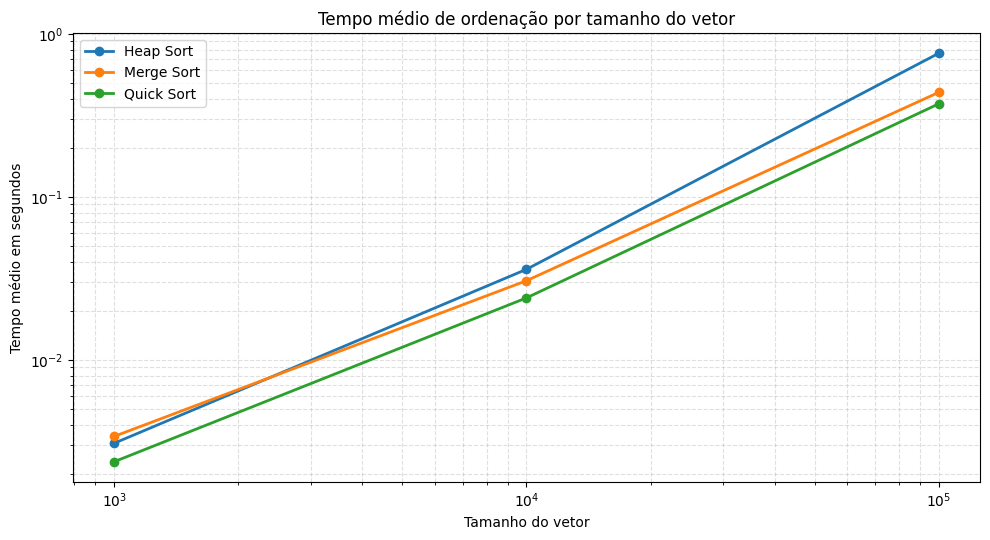

In [5]:
import matplotlib.pyplot as plt

dfValidos = dfResultados.copy()
tabelaTempo = dfValidos.pivot(index="tamanho", columns="algoritmo", values="tempoMedio")
tabelaTempo = tabelaTempo.sort_index()

eixoX = tabelaTempo.index.to_numpy()
colunasAlgoritmos = tabelaTempo.columns.to_numpy()

plt.figure(figsize=(10, 5.5))
for algoritmo in colunasAlgoritmos:
    eixoY = tabelaTempo[algoritmo].to_numpy()
    plt.plot(eixoX, eixoY, marker="o", linewidth=2, label=algoritmo)

plt.xscale("log")
plt.yscale("log")
plt.title("Tempo médio de ordenação por tamanho do vetor")
plt.xlabel("Tamanho do vetor")
plt.ylabel("Tempo médio em segundos")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


## Algoritmo mais rápido por tamanho

In [6]:
maisRapidos = (
    dfResultados
    .sort_values(["tamanho", "tempoMedio"])
    .groupby("tamanho")
    .first()
    .reset_index()[["tamanho", "algoritmo", "tempoMedio"]]
)

maisRapidos


,tamanho,algoritmo,tempoMedio
0,1000,Quick Sort,0.002368
1,10000,Quick Sort,0.023977
2,100000,Quick Sort,0.372410


## Análise

Os resultados são coerentes com a complexidade teórica. Merge Sort e Heap Sort possuem pior caso O(n log n), por isso tendem a crescer de forma mais controlada quando o tamanho do vetor aumenta. Quick Sort possui pior caso O(n²), mas com vetores aleatórios normalmente se aproxima do comportamento médio O(n log n), o que explica tempos competitivos nos testes.

A quantidade de trocas ou movimentações também cresce com o tamanho da entrada. Porém, tempo de execução não depende apenas dessa quantidade: custo de chamadas recursivas, uso de memória auxiliar, acesso a listas e constantes internas de cada algoritmo também influenciam o resultado prático.

Para os vetores aleatórios usados nesta atividade, os algoritmos O(n log n) foram adequados para 100.000 elementos.